# Predictive Maintenance Alerts

## Practical Lab 1: Streaming Data for Predictive Maintenance with Linear Regression-Based Alerts

This project extends the Data Stream Visualization Workshop by applying linear regression and residual-based anomaly detection to industrial robot current data.

The system trains regression models for Axes #1–#8 using training data stored in PostgreSQL, analyzes residuals to determine anomaly thresholds, and evaluates synthetically generated streaming test data to identify sustained Alert and Error conditions.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Object-oriented database manager for the Neon PostgreSQL connection.
from src.database_manager import DatabaseManager

# Confirm that the notebook is using this project's virtual environment.
print("Python:", sys.executable)

Python: c:\Users\sybun\OneDrive\Desktop\Python Projects Class\Foundations of ML Frameworks\PredictiveMaintenanceAlerts\.venv\Scripts\python.exe


In [2]:
# Create the database manager using the connection stored in .env.
db = DatabaseManager()

# Verify that the application can connect to Neon.
if db.test_connection():
    print("Database connection successful.")

# Create the required project tables if they do not already exist.
db.create_tables()

print("Project database tables are ready.")

Database connection successful.
Project database tables are ready.


In [3]:
# Load the original robot current dataset from the local data folder.
# This CSV will be uploaded to Neon and used as the project's training data.
training_df = pd.read_csv("data/robot_data.csv")

# Verify that the file loaded correctly before doing any preprocessing.
print("Training data shape:", training_df.shape)
display(training_df.head())

Training data shape: (39672, 16)


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


In [4]:
# Define the eight current axes required by the assignment.
axis_columns = [f"Axis #{i}" for i in range(1, 9)]

# Keep only the columns needed for regression and anomaly detection.
training_df = training_df[
    ["Trait"] + axis_columns + ["Time"]
].copy()

# Convert Time into a proper datetime value for PostgreSQL and later analysis.
training_df["Time"] = pd.to_datetime(
    training_df["Time"],
    utc=True
)

# Verify the prepared training dataset.
print("Prepared training data shape:", training_df.shape)
print("\nMissing values:")
display(training_df.isna().sum())

display(training_df.head())

Prepared training data shape: (39672, 10)

Missing values:


Trait      0
Axis #1    0
Axis #2    0
Axis #3    0
Axis #4    0
Axis #5    0
Axis #6    0
Axis #7    0
Axis #8    0
Time       0
dtype: int64

,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:23.660000+00:00
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:25.472000+00:00
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:27.348000+00:00
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:29.222000+00:00
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:31.117000+00:00


In [5]:
# Clear old training records to prevent duplicates when the notebook is rerun.
db.clear_training_data()

# Store the prepared training dataset in Neon PostgreSQL.
db.upload_training_data(training_df)

print(f"{len(training_df):,} training records uploaded to Neon.")

39,672 training records uploaded to Neon.


In [6]:
# Retrieve the training dataset from the cloud database.
# The regression models will be trained from this retrieved data.
db_training_df = db.get_training_data()

print(f"{len(db_training_df):,} records retrieved from Neon.")
display(db_training_df.head())

39,672 records retrieved from Neon.


,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,timestamp
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:23.660000+00:00
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:25.472000+00:00
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:27.348000+00:00
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:29.222000+00:00
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022-10-17 12:18:31.117000+00:00


In [7]:
# Check the structure and descriptive statistics of the database training data.
print("Database training data shape:", db_training_df.shape)

display(
    db_training_df[
        [f"axis_{i}" for i in range(1, 9)]
    ].describe()
)

Database training data shape: (39672, 10)


,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8
count,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000,39672.000000
mean,0.725743,3.613374,2.710336,0.620222,0.954521,0.599427,0.870145,0.102214
std,2.162120,6.879962,5.111901,1.574897,2.100186,1.815498,2.166811,0.423075
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.312710,4.217190,4.586190,0.516190,0.800090,0.361330,0.310030,0.078480
max,23.609300,51.713230,41.855560,15.666300,20.750760,20.931420,8.108480,5.905640


In [8]:
# Import the regression analyzer used to train the eight axis models.
from src.regression_model import RegressionAnalyzer

In [9]:
# Train one Time -> Axis regression model for each current axis.
regression = RegressionAnalyzer()

model_df = regression.fit_models(db_training_df)

# Display slope, intercept, and model fit for all eight regressions.
model_summary = regression.get_model_summary()

display(model_summary)

,Axis,Slope,Intercept,R²
0,Axis #1,-1.176729e-07,0.730542,1.584839e-06
1,Axis #2,2.194203e-06,3.523886,5.442193e-05
2,Axis #3,-5.777186e-07,2.733898,6.833765e-06
3,Axis #4,3.890034e-07,0.604357,3.264337e-05
4,Axis #5,8.381178e-08,0.951103,8.520927e-07
5,Axis #6,4.744455e-07,0.580077,3.654041e-05
6,Axis #7,5.537186e-07,0.847563,3.494045e-05
7,Axis #8,8.499989e-08,0.098748,2.159701e-05


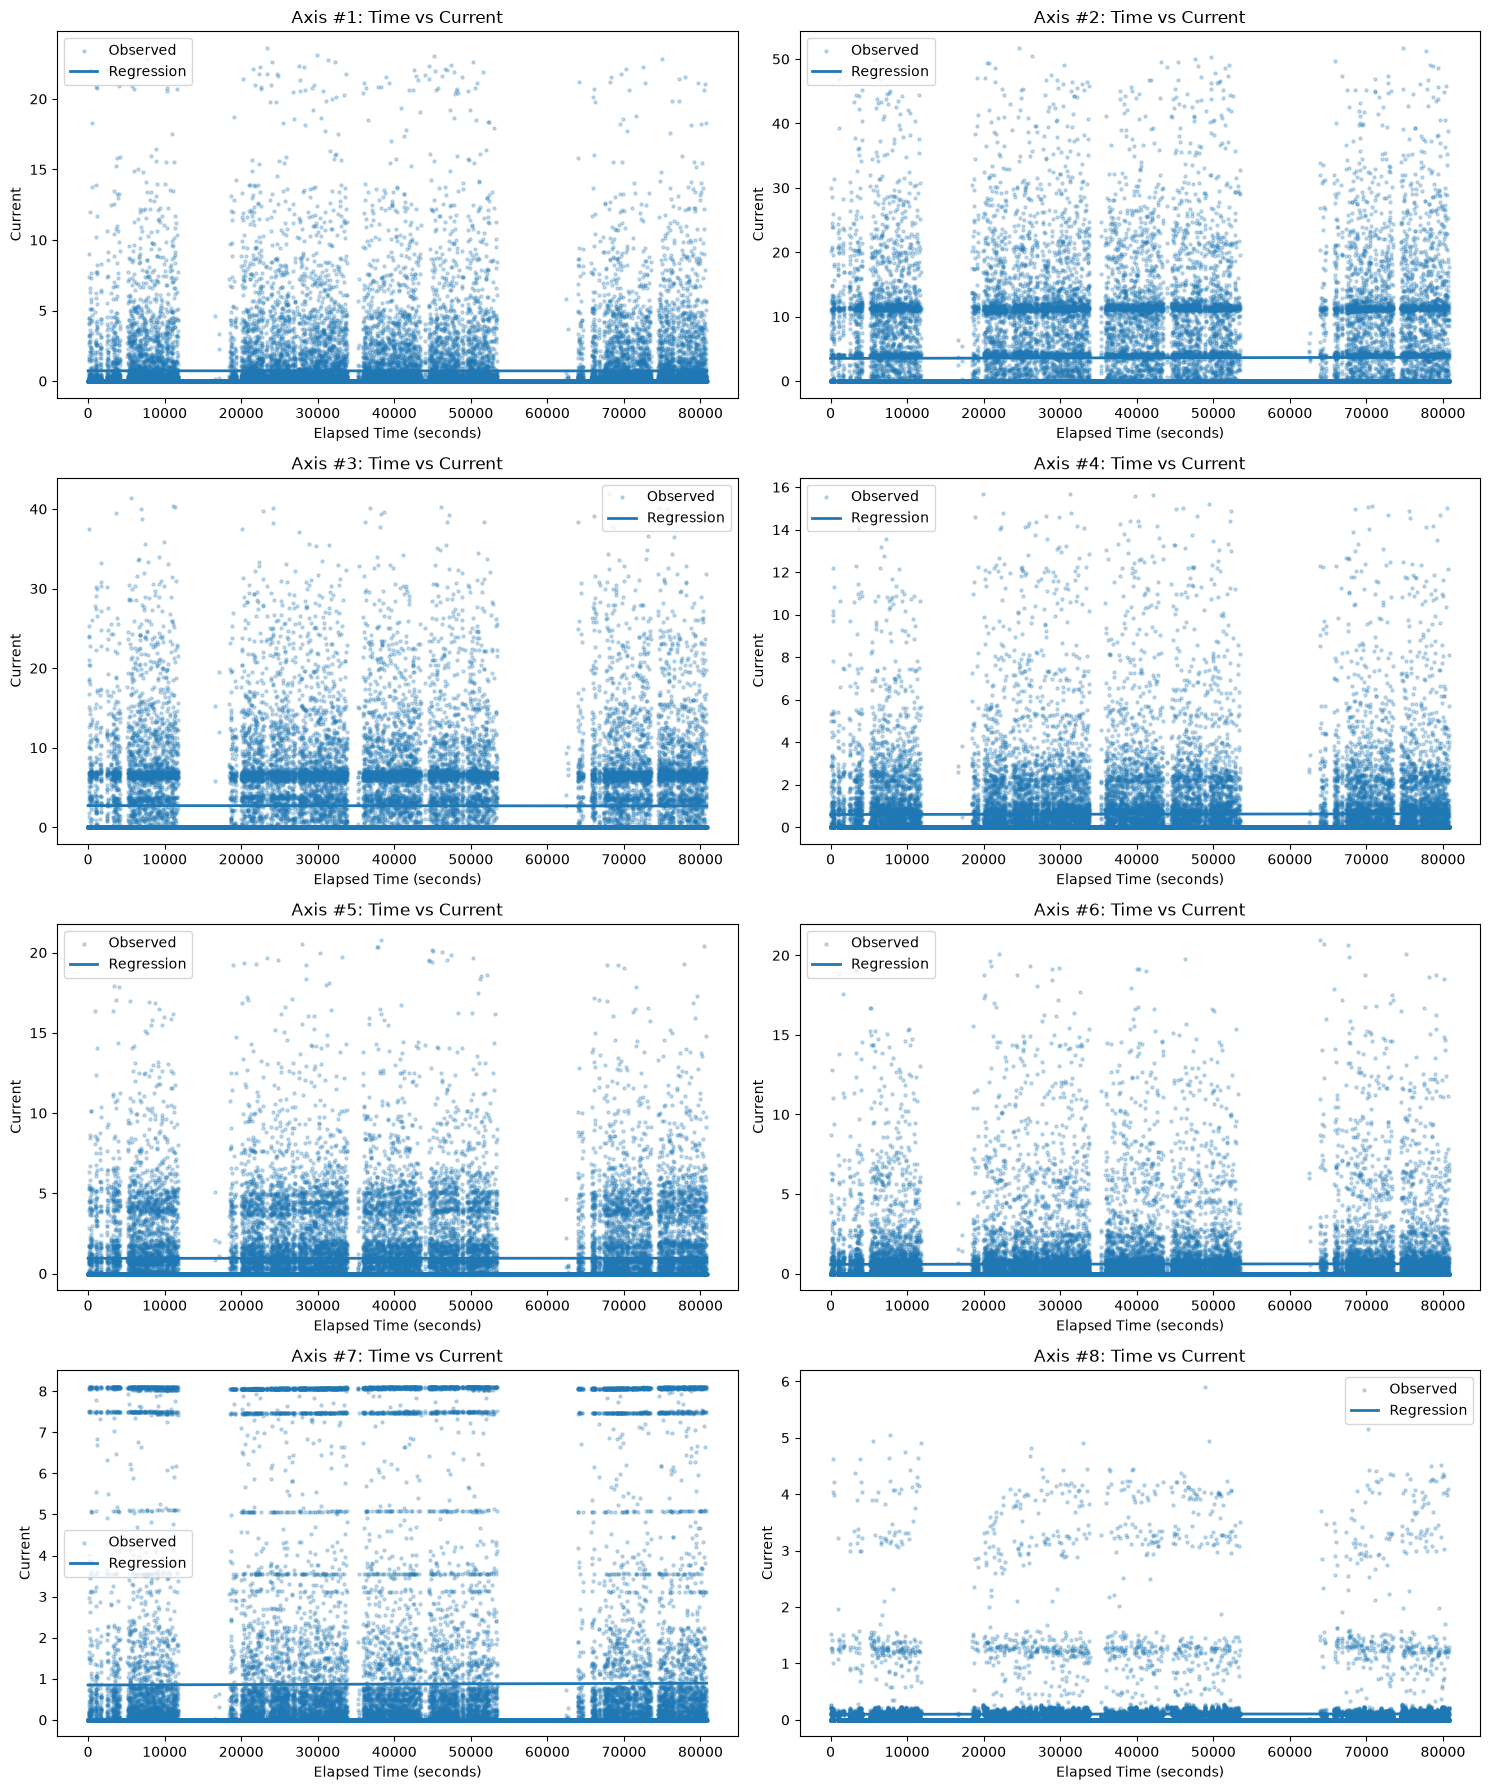

In [10]:
# Plot observed current values and fitted regression lines for all eight axes.
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for axis in range(1, 9):
    ax = axes[axis - 1]

    # Actual current measurements.
    ax.scatter(
        model_df["elapsed_seconds"],
        model_df[f"axis_{axis}"],
        s=5,
        alpha=0.25,
        label="Observed"
    )

    # Current predicted by the linear regression model.
    ax.plot(
        model_df["elapsed_seconds"],
        regression.results[axis]["predictions"],
        linewidth=2,
        label="Regression"
    )

    ax.set_title(f"Axis #{axis}: Time vs Current")
    ax.set_xlabel("Elapsed Time (seconds)")
    ax.set_ylabel("Current")
    ax.legend()

plt.tight_layout()
plt.show()

In [11]:
# Summarize residual behavior for each regression model.
residual_summary = []

for axis in range(1, 9):
    residuals = regression.results[axis]["residuals"]

    residual_summary.append({
        "Axis": f"Axis #{axis}",
        "Mean Residual": np.mean(residuals),
        "Std Residual": np.std(residuals),
        "95th Percentile": np.percentile(residuals, 95),
        "99th Percentile": np.percentile(residuals, 99),
        "Max Residual": np.max(residuals)
    })

residual_summary_df = pd.DataFrame(residual_summary)

display(residual_summary_df)

,Axis,Mean Residual,Std Residual,95th Percentile,99th Percentile,Max Residual
0,Axis #1,-5.731339e-17,2.162091,3.622423,10.637570,22.881511
1,Axis #2,2.980296e-16,6.879688,13.548942,27.827261,48.082660
2,Axis #3,3.668057e-16,5.111819,9.756149,22.004903,39.160990
3,Axis #4,6.304473e-17,1.574851,2.506291,7.724843,15.054179
4,Axis #5,-8.023874e-17,2.100159,4.106583,8.931155,19.796448
5,Axis #6,-1.203581e-16,1.815442,2.498980,9.737241,20.320990
6,Axis #7,-1.719402e-16,2.166746,7.175265,7.227199,7.260771
7,Axis #8,0.000000e+00,0.423065,0.096614,2.866628,5.802731


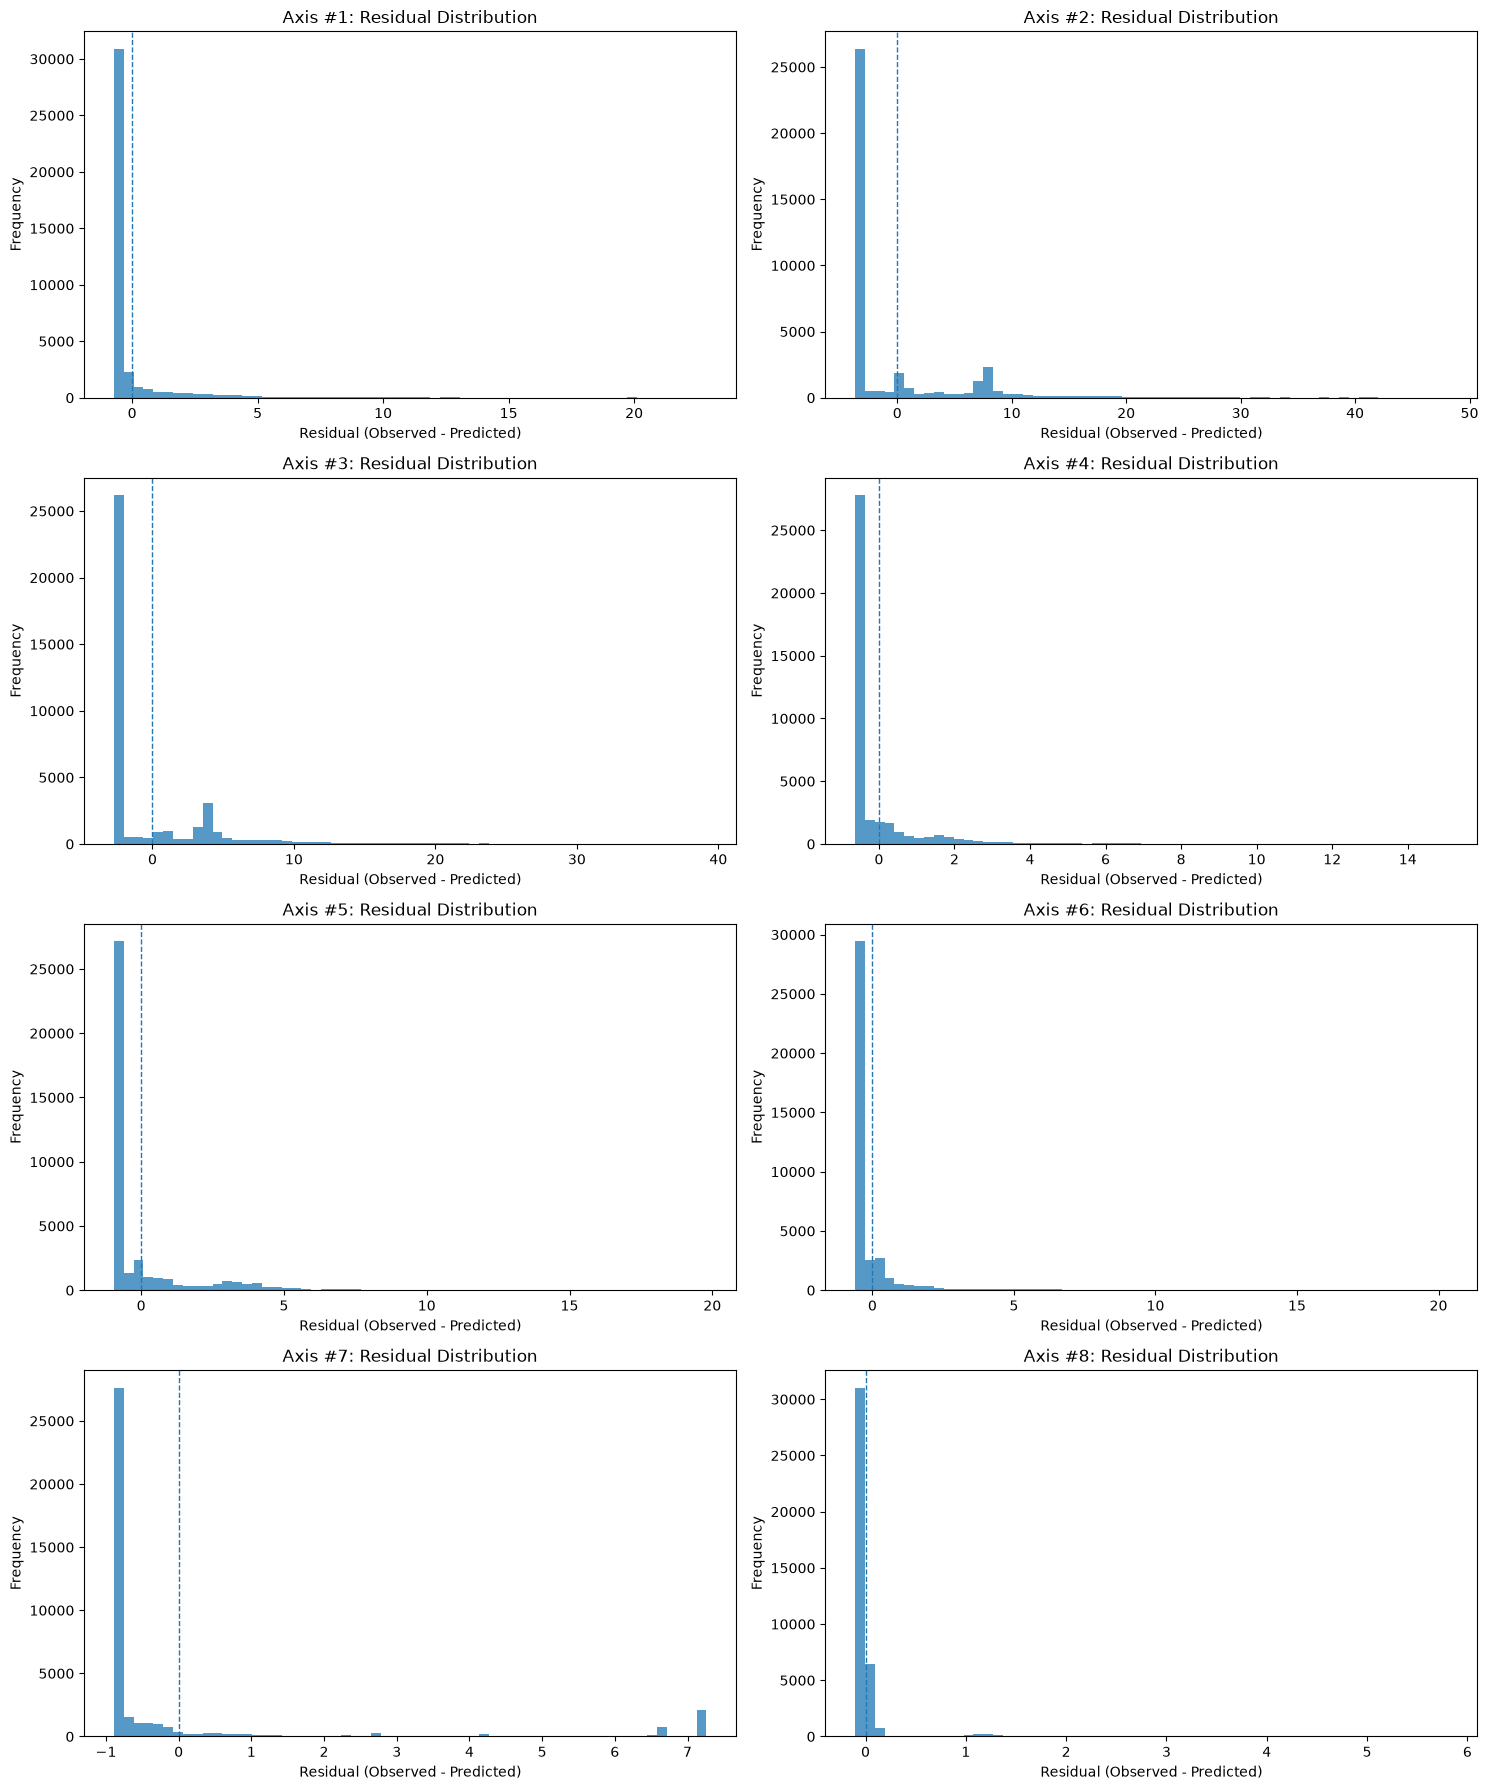

In [12]:
# Plot the residual distributions to identify typical deviations and outliers.
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for axis in range(1, 9):
    ax = axes[axis - 1]

    residuals = regression.results[axis]["residuals"]

    ax.hist(
        residuals,
        bins=60,
        alpha=0.75
    )

    # A residual of zero means observed current exactly matched prediction.
    ax.axvline(0, linestyle="--", linewidth=1)

    ax.set_title(f"Axis #{axis}: Residual Distribution")
    ax.set_xlabel("Residual (Observed - Predicted)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [13]:
# Calculate the time between consecutive training observations.
# This helps us choose a meaningful sustained-duration threshold (T).
time_differences = (
    model_df["timestamp"]
    .sort_values()
    .diff()
    .dt.total_seconds()
    .dropna()
)

print("Sampling interval statistics (seconds):")
display(time_differences.describe())

print(
    "Median sampling interval:",
    time_differences.median(),
    "seconds"
)

Sampling interval statistics (seconds):


count    39671.000000
mean         2.036625
std          2.713063
min          1.714000
25%          1.860000
50%          1.891000
75%          1.923000
max        402.538000
Name: timestamp, dtype: float64

Median sampling interval: 1.891 seconds


In [14]:
# Use training residual percentiles as evidence-based anomaly thresholds.
thresholds = {}

for axis in range(1, 9):
    residuals = regression.results[axis]["residuals"]

    thresholds[axis] = {
        "MinC": np.percentile(residuals, 95),
        "MaxC": np.percentile(residuals, 99)
    }

threshold_df = pd.DataFrame([
    {
        "Axis": f"Axis #{axis}",
        "MinC (95th percentile)": values["MinC"],
        "MaxC (99th percentile)": values["MaxC"]
    }
    for axis, values in thresholds.items()
])

display(threshold_df)

,Axis,MinC (95th percentile),MaxC (99th percentile)
0,Axis #1,3.622423,10.637570
1,Axis #2,13.548942,27.827261
2,Axis #3,9.756149,22.004903
3,Axis #4,2.506291,7.724843
4,Axis #5,4.106583,8.931155
5,Axis #6,2.498980,9.737241
6,Axis #7,7.175265,7.227199
7,Axis #8,0.096614,2.866628


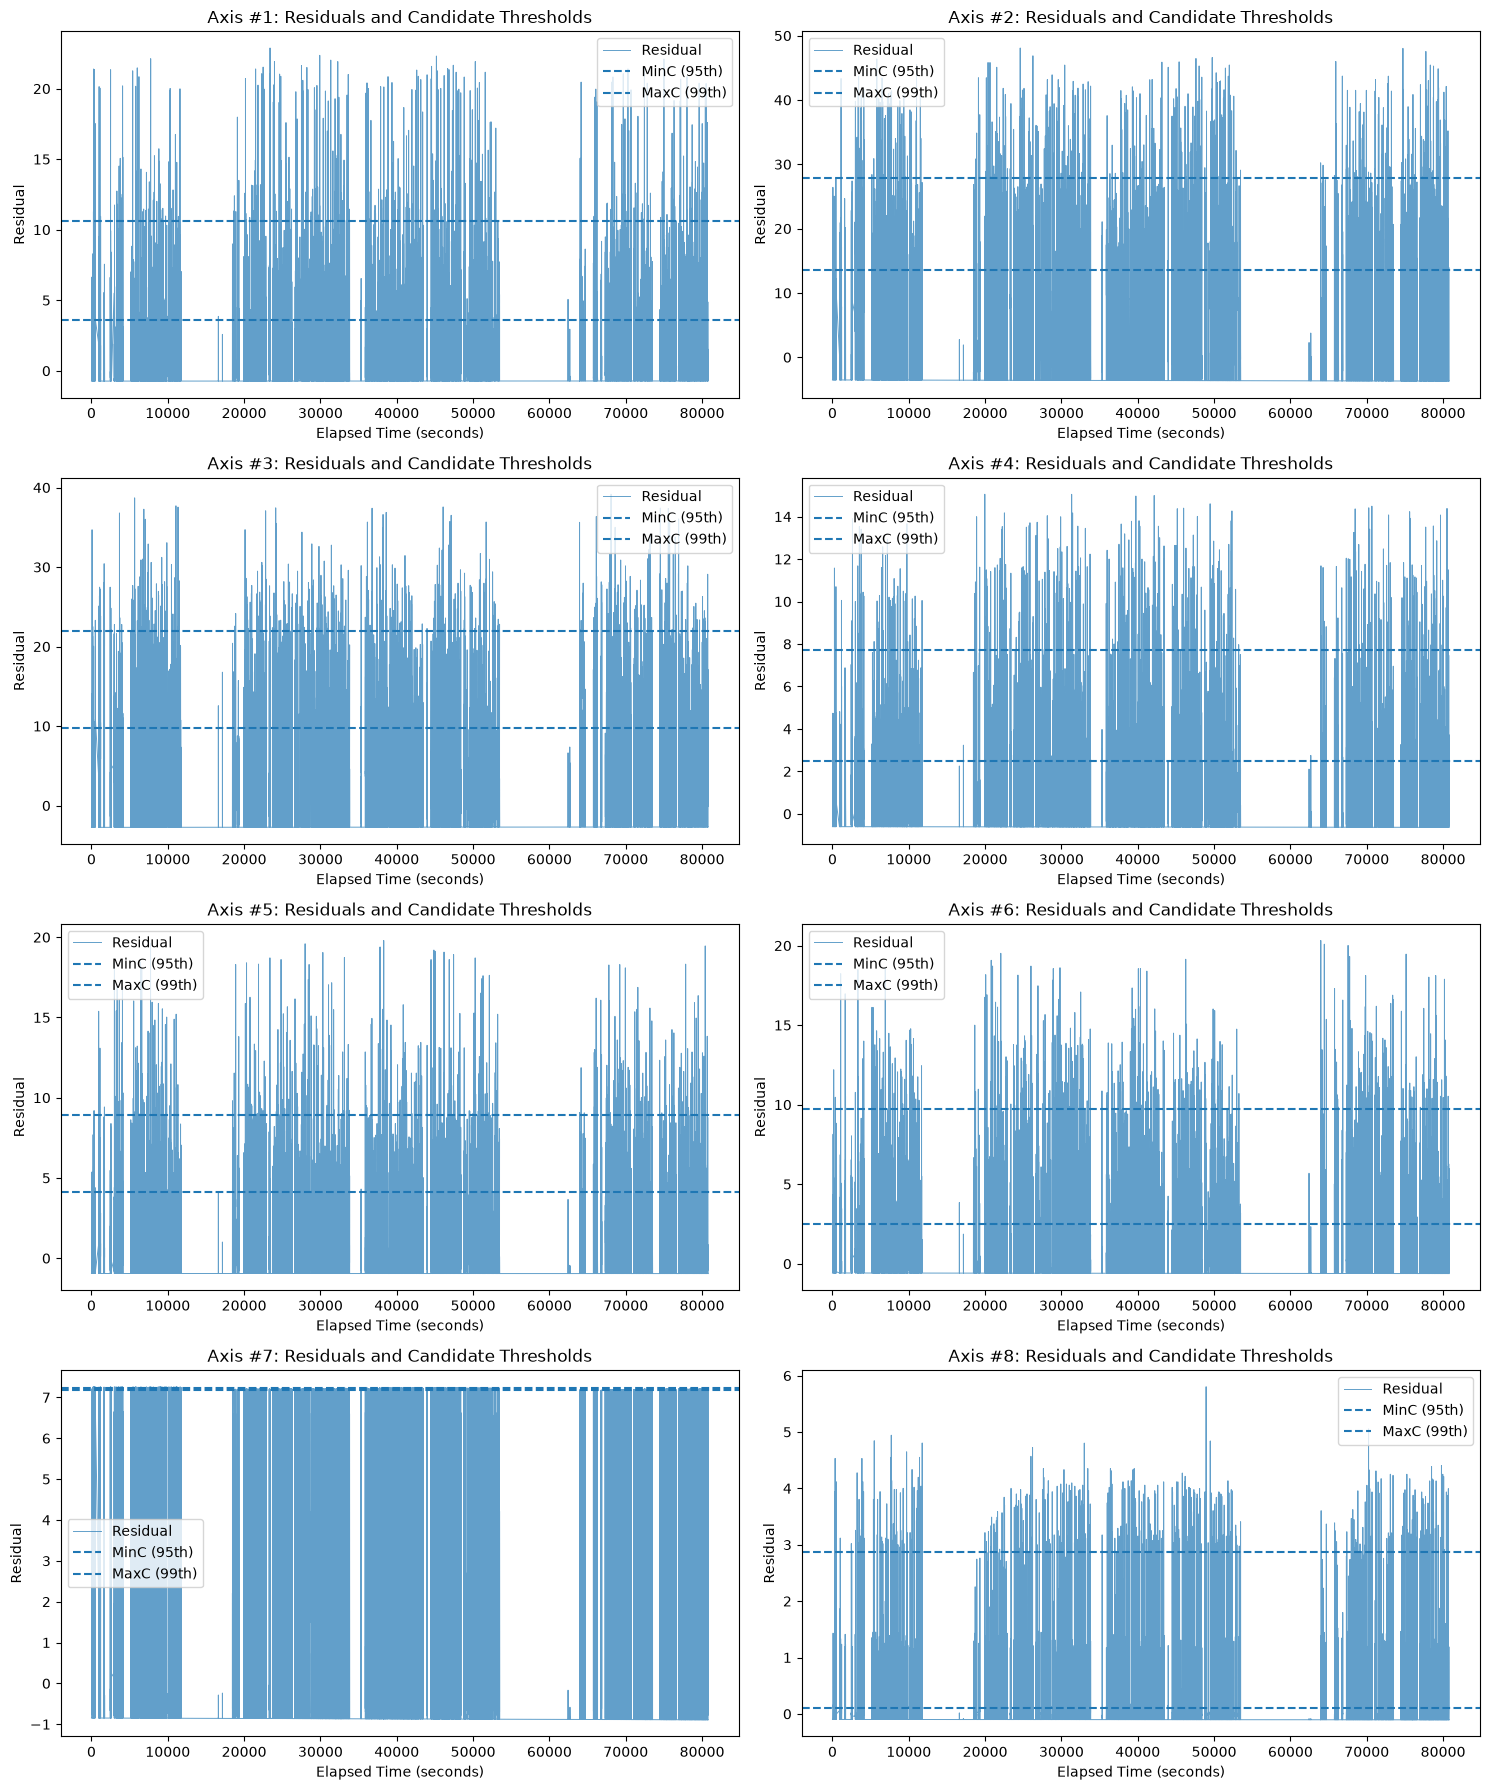

In [15]:
# Plot residuals over time with the candidate Alert and Error thresholds.
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for axis in range(1, 9):
    ax = axes[axis - 1]

    residuals = regression.results[axis]["residuals"]

    ax.plot(
        model_df["elapsed_seconds"],
        residuals,
        linewidth=0.7,
        alpha=0.7,
        label="Residual"
    )

    ax.axhline(
        thresholds[axis]["MinC"],
        linestyle="--",
        label="MinC (95th)"
    )

    ax.axhline(
        thresholds[axis]["MaxC"],
        linestyle="--",
        label="MaxC (99th)"
    )

    ax.set_title(f"Axis #{axis}: Residuals and Candidate Thresholds")
    ax.set_xlabel("Elapsed Time (seconds)")
    ax.set_ylabel("Residual")
    ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# Require an abnormal deviation to persist for about three typical sampling intervals.
T = 6.0

print(f"Median sampling interval: {time_differences.median():.3f} seconds")
print(f"Sustained-duration threshold (T): {T:.1f} seconds")
print("\nThreshold methodology:")
print("MinC = 95th percentile of training residuals")
print("MaxC = 99th percentile of training residuals")
print("T    = 6 seconds (~3 normal sampling intervals)")

Median sampling interval: 1.891 seconds
Sustained-duration threshold (T): 6.0 seconds

Threshold methodology:
MinC = 95th percentile of training residuals
MaxC = 99th percentile of training residuals
T    = 6 seconds (~3 normal sampling intervals)


### Threshold Selection

The anomaly thresholds were derived from the training residuals rather than selected arbitrarily.

- **MinC** is the 95th percentile of the residual distribution for each axis. A positive deviation above this level is unusually high relative to the training data and is considered an Alert candidate.
- **MaxC** is the 99th percentile of the residual distribution for each axis. This represents a more extreme positive deviation and is considered an Error candidate.
- **T = 6 seconds** was selected as the sustained-duration requirement. The median interval between training observations is approximately 1.891 seconds, so six seconds represents roughly three typical sampling intervals. This prevents isolated spikes from immediately generating maintenance events.

Per-axis MinC and MaxC values are used because the eight axes operate on substantially different current scales and have different residual distributions.

In [17]:
# Generate a new synthetic testing dataset using training metadata.
from src.data_generator import SyntheticDataGenerator

generator = SyntheticDataGenerator(random_state=42)

synthetic_df = generator.generate(
    db_training_df,
    n_samples=300
)

print("Synthetic test data shape:", synthetic_df.shape)
display(synthetic_df.head())

Synthetic test data shape: (300, 26)


,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,timestamp,...,axis_4_zscore,axis_4_normalized,axis_5_zscore,axis_5_normalized,axis_6_zscore,axis_6_normalized,axis_7_zscore,axis_7_normalized,axis_8_zscore,axis_8_normalized
0,SYNTHETIC,0.506119,11.664388,1.275581,1.421699,2.548071,1.635583,0.036782,0.077323,2022-10-18 10:45:00.519000+00:00,...,0.508914,0.090749,0.758776,0.122794,0.570735,0.078140,-0.384609,0.004536,-0.058836,0.013093
1,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:02.410000+00:00,...,-0.393822,0.000000,-0.454499,0.000000,-0.330176,0.000000,-0.401584,0.000000,-0.241602,0.000000
2,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:04.301000+00:00,...,-0.393822,0.000000,-0.454499,0.000000,-0.330176,0.000000,-0.401584,0.000000,-0.241602,0.000000
3,SYNTHETIC,1.894570,15.354558,1.135949,1.300211,5.014444,0.141356,8.099284,0.017832,2022-10-18 10:45:06.192000+00:00,...,0.431773,0.082994,1.933150,0.241651,-0.252315,0.006753,3.336346,0.998866,-0.199453,0.003020
4,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:08.083000+00:00,...,-0.393822,0.000000,-0.454499,0.000000,-0.330176,0.000000,-0.401584,0.000000,-0.241602,0.000000


In [18]:
# Compare synthetic testing statistics with the original training statistics.
axis_db_columns = [f"axis_{i}" for i in range(1, 9)]

comparison = pd.DataFrame({
    "Training Mean": db_training_df[axis_db_columns].mean(),
    "Synthetic Mean": synthetic_df[axis_db_columns].mean(),
    "Training Std": db_training_df[axis_db_columns].std(),
    "Synthetic Std": synthetic_df[axis_db_columns].std()
})

display(comparison)

,Training Mean,Synthetic Mean,Training Std,Synthetic Std
axis_1,0.725743,0.843594,2.162120,2.280664
axis_2,3.613374,3.673686,6.879962,7.592954
axis_3,2.710336,2.546965,5.111901,4.530104
axis_4,0.620222,0.732308,1.574897,1.783595
axis_5,0.954521,0.856414,2.100186,1.722585
axis_6,0.599427,0.612449,1.815498,1.869835
axis_7,0.870145,0.962454,2.166811,2.287158
axis_8,0.102214,0.092169,0.423075,0.398135


In [19]:
# Create a controlled copy of the synthetic baseline.
synthetic_test_df = synthetic_df.copy()

# Calculate elapsed time using the same origin as model training.
training_start = pd.to_datetime(
    db_training_df["timestamp"],
    utc=True
).min()

test_elapsed_seconds = (
    pd.to_datetime(synthetic_test_df["timestamp"], utc=True)
    - training_start
).dt.total_seconds()

# Define sustained test regions.
alert_start = 80
alert_end = 86

error_start = 180
error_end = 186

# Axis #2: force the residual between MinC and MaxC for an Alert.
axis_2_predictions = regression.models[2].predict(
    pd.DataFrame({
        "elapsed_seconds": test_elapsed_seconds
    })
)

alert_deviation = (
    thresholds[2]["MinC"]
    + thresholds[2]["MaxC"]
) / 2

synthetic_test_df.loc[
    alert_start:alert_end,
    "axis_2"
] = (
    axis_2_predictions[alert_start:alert_end + 1]
    + alert_deviation
)

# Axis #6: force the residual above MaxC for an Error.
axis_6_predictions = regression.models[6].predict(
    pd.DataFrame({
        "elapsed_seconds": test_elapsed_seconds
    })
)

error_deviation = thresholds[6]["MaxC"] * 1.20

synthetic_test_df.loc[
    error_start:error_end,
    "axis_6"
] = (
    axis_6_predictions[error_start:error_end + 1]
    + error_deviation
)

print(
    f"Axis #2 controlled Alert residual: "
    f"{alert_deviation:.3f}"
)

print(
    f"Axis #6 controlled Error residual: "
    f"{error_deviation:.3f}"
)

Axis #2 controlled Alert residual: 20.688
Axis #6 controlled Error residual: 11.685


In [20]:
# Recalculate standardized and normalized values after anomaly injection.
standardized = generator.standard_scaler.transform(
    synthetic_test_df[axis_db_columns]
)

normalized = generator.minmax_scaler.transform(
    synthetic_test_df[axis_db_columns]
)

for i, column in enumerate(axis_db_columns):
    synthetic_test_df[f"{column}_zscore"] = standardized[:, i]
    synthetic_test_df[f"{column}_normalized"] = normalized[:, i]

print("Synthetic test preprocessing updated.")

Synthetic test preprocessing updated.


In [21]:
# Save the completed synthetic testing dataset for reproducibility.
synthetic_test_df.to_csv(
    "data/synthetic_test_data.csv",
    index=False
)

print(
    f"Saved {len(synthetic_test_df)} synthetic test records "
    "to data/synthetic_test_data.csv"
)

Saved 300 synthetic test records to data/synthetic_test_data.csv


In [22]:
# Detect sustained Alert and Error conditions in the synthetic stream.
from src.anomaly_detector import AnomalyDetector

detector = AnomalyDetector(
    regression_analyzer=regression,
    thresholds=thresholds,
    duration_threshold=T
)

detected_df, events_df = detector.detect(
    synthetic_test_df,
    db_training_df
)

print(f"Detected {len(events_df)} sustained events.")

display(events_df)

Detected 2 sustained events.


,axis,event_type,start_time,end_time,duration_seconds,max_deviation
0,2,Alert,2022-10-18 10:47:31.799000+00:00,2022-10-18 10:47:43.145000+00:00,11.346,20.688101
1,6,Error,2022-10-18 10:50:40.899000+00:00,2022-10-18 10:50:52.245000+00:00,11.346,11.684689


In [23]:
# Save detected maintenance events as a structured CSV log.
events_df.to_csv(
    "data/alert_error_log.csv",
    index=False
)

print("Event log saved to data/alert_error_log.csv")

Event log saved to data/alert_error_log.csv


In [24]:
# Simulate the timestamp-ordered synthetic data flow into Neon.
from src.streaming_simulator import StreamingSimulator

streamer = StreamingSimulator(database_manager=db)

records_streamed = streamer.stream(synthetic_test_df)

print(f"{records_streamed} synthetic records streamed to Neon.")

300 synthetic records streamed to Neon.


In [25]:
# Retrieve the simulated stream from Neon to verify ingestion.
streamed_df = db.get_stream_data()

print(f"{len(streamed_df)} streaming records retrieved from Neon.")
display(streamed_df.head())

300 streaming records retrieved from Neon.


,trait,axis_1,axis_2,axis_3,axis_4,axis_5,axis_6,axis_7,axis_8,timestamp
0,SYNTHETIC,0.506119,11.664388,1.275581,1.421699,2.548071,1.635583,0.036782,0.077323,2022-10-18 10:45:00.519000+00:00
1,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:02.410000+00:00
2,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:04.301000+00:00
3,SYNTHETIC,1.894570,15.354558,1.135949,1.300211,5.014444,0.141356,8.099284,0.017832,2022-10-18 10:45:06.192000+00:00
4,SYNTHETIC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2022-10-18 10:45:08.083000+00:00


In [26]:
# Run anomaly detection on the data retrieved back from Neon.
database_detected_df, database_events_df = detector.detect(
    streamed_df,
    db_training_df
)

print(
    f"Detected {len(database_events_df)} sustained events "
    "after the Neon database round trip."
)

display(database_events_df)

Detected 2 sustained events after the Neon database round trip.


,axis,event_type,start_time,end_time,duration_seconds,max_deviation
0,2,Alert,2022-10-18 10:47:31.799000+00:00,2022-10-18 10:47:43.145000+00:00,11.346,20.688101
1,6,Error,2022-10-18 10:50:40.899000+00:00,2022-10-18 10:50:52.245000+00:00,11.346,11.684689


In [27]:
# Save the final database-validated maintenance events.
db.clear_anomaly_events()
db.upload_anomaly_events(database_events_df)

database_events_df.to_csv(
    "data/alert_error_log.csv",
    index=False
)

print(
    f"{len(database_events_df)} anomaly events saved "
    "to Neon and data/alert_error_log.csv."
)

2 anomaly events saved to Neon and data/alert_error_log.csv.


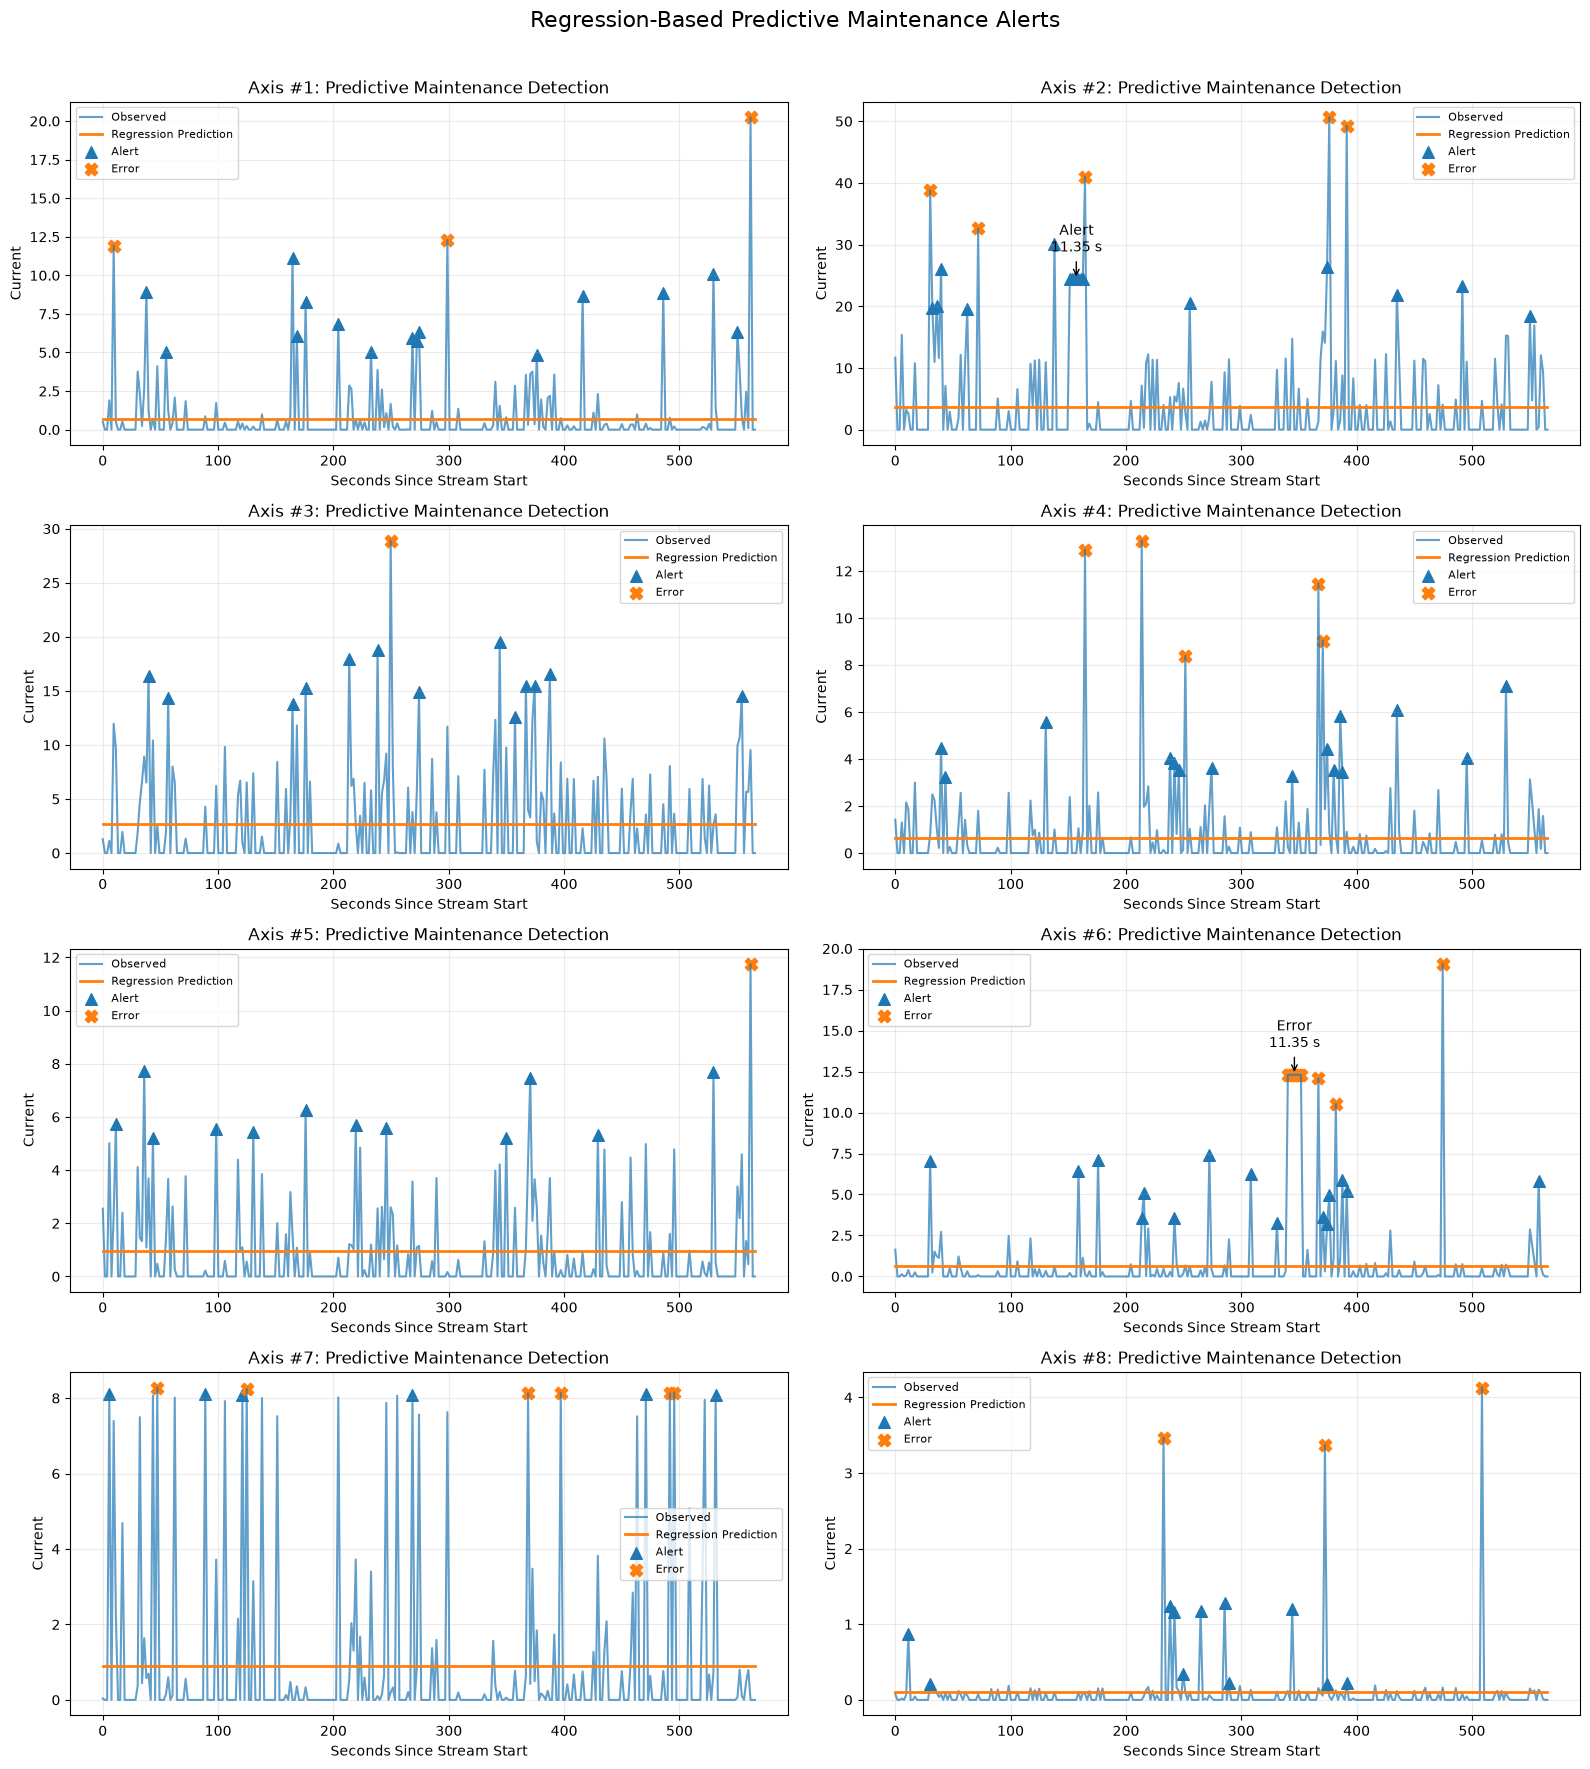

Final visualization saved to figures/predictive_maintenance_alerts.png


In [28]:
# Visualize and save the final database-validated results.
from src.visualizer import MaintenanceVisualizer

visualizer = MaintenanceVisualizer()

fig = visualizer.plot_detection_results(
    database_detected_df,
    database_events_df
)

fig.savefig(
    "figures/predictive_maintenance_alerts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    "Final visualization saved to "
    "figures/predictive_maintenance_alerts.png"
)